In [ ]:
# Load the Iris dataset into a pandas DataFrame

import pandas as pd
from sklearn import datasets

iris= pd.DataFrame(datasets.load_iris().data)

# Add column names to the dataset
iris.columns = datasets.load_iris().feature_names

# Add the target variable representing flower type
iris['type'] = datasets.load_iris().target

# Convert the target variable to an object data type
iris['type']=iris['type'].astype('object')

iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
display(iris.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),new
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,20.553604
std,0.828066,0.435866,1.765298,0.762238,29.922686
min,4.300000,2.000000,1.000000,0.100000,1.261500
25%,5.100000,2.800000,1.600000,0.300000,1.938853
50%,5.800000,3.000000,4.350000,1.300000,2.970235
75%,6.400000,3.300000,5.100000,1.800000,42.302941
max,7.900000,4.400000,6.900000,2.500000,142.133333


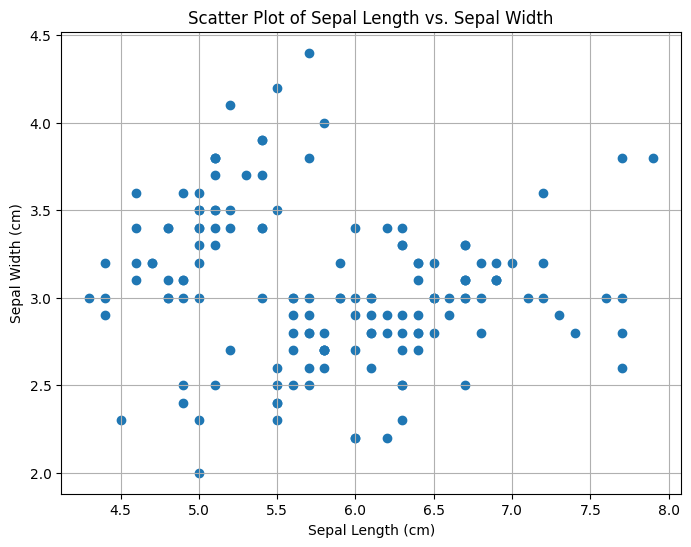

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(x=iris['sepal length (cm)'], y=iris['sepal width (cm)'])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width')
plt.grid(True)
plt.show()

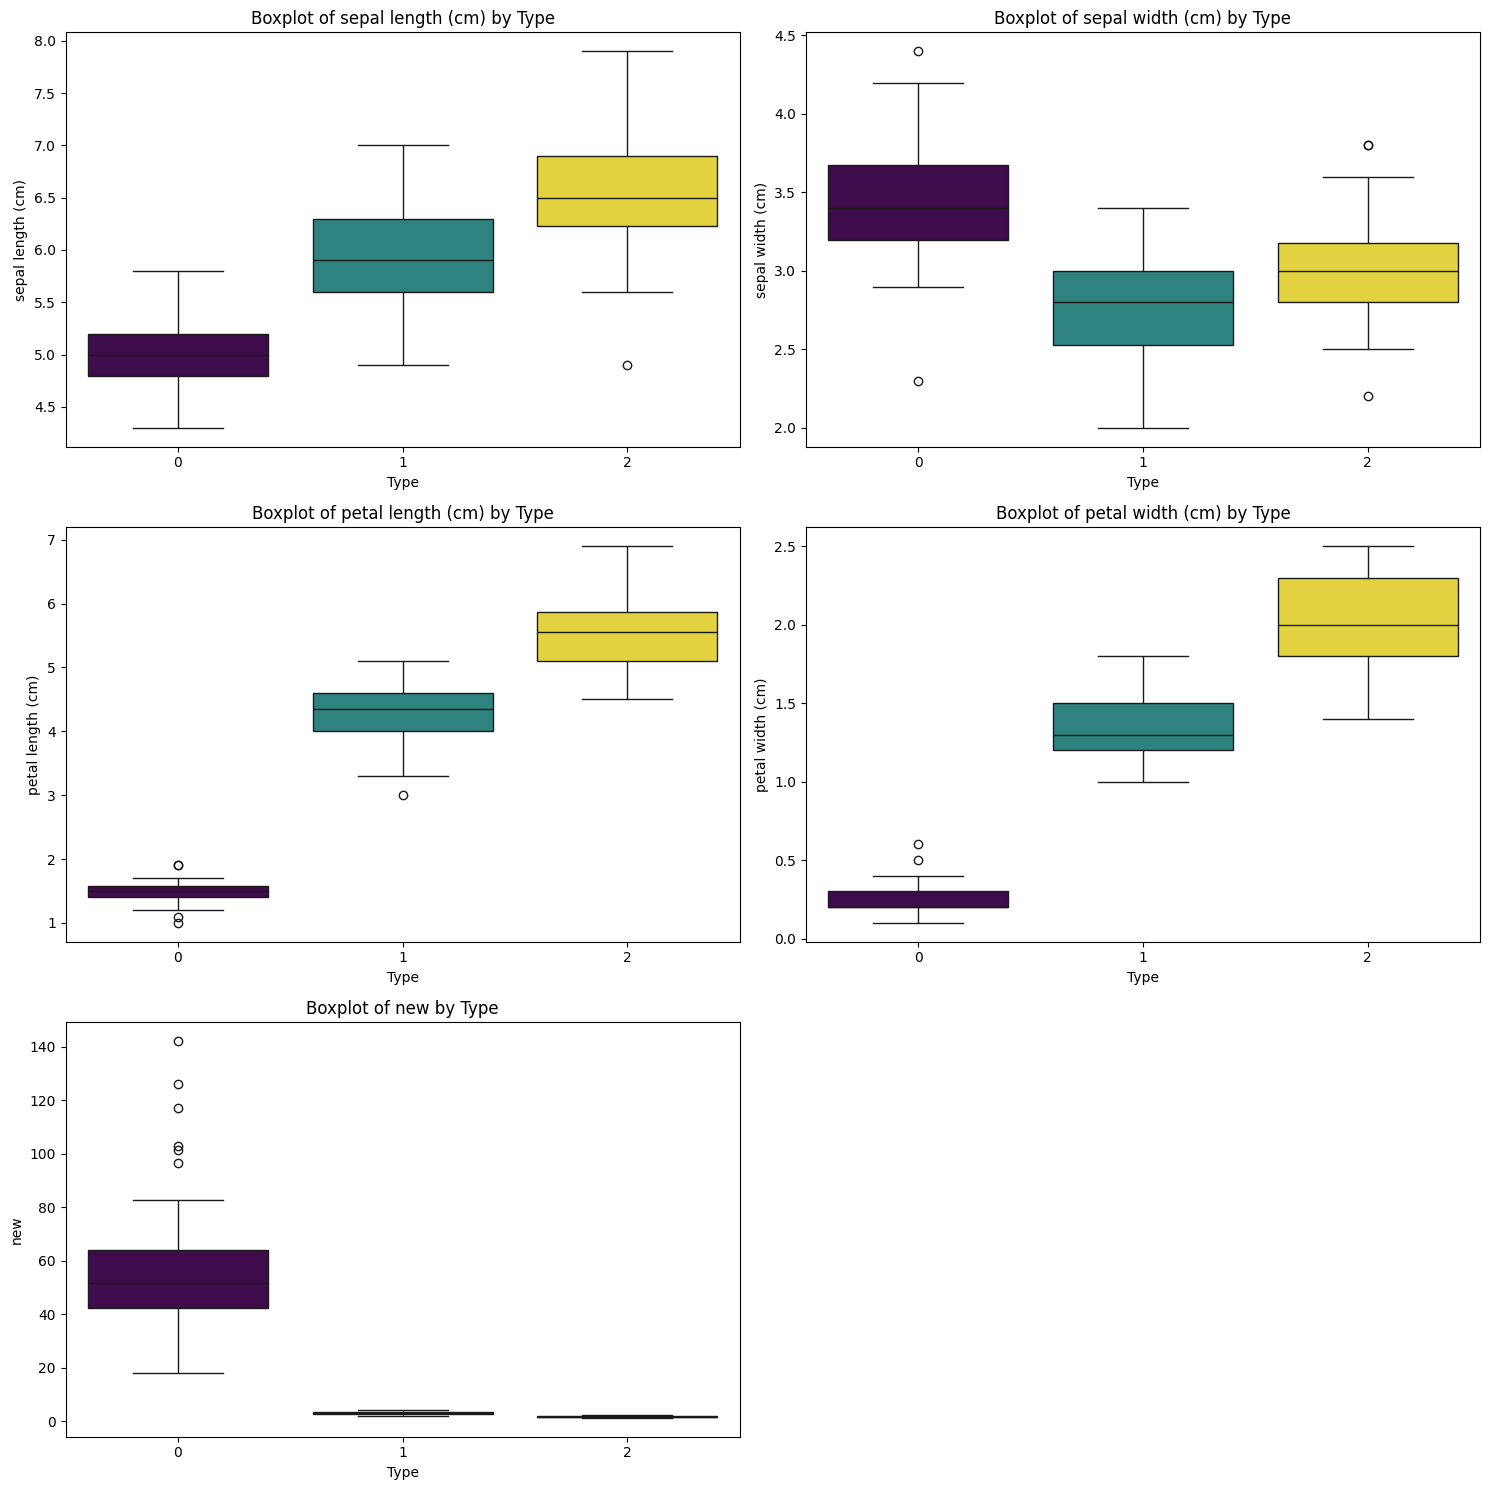

In [ ]:
import seaborn as sns

# Get numerical columns, excluding 'type' as it's the grouping variable
feature_columns = iris.columns.drop('type')

plt.figure(figsize=(15, 15)) # Increased figure height to accommodate 3 rows

for i, col in enumerate(feature_columns):
    plt.subplot(3, 2, i + 1) # Changed to 3 rows, 2 columns to fit 5 plots
    sns.boxplot(x='type', y=col, data=iris, palette='viridis', hue='type', legend=False)
    plt.title(f'Boxplot of {col} by Type')
    plt.xlabel('Type')
    plt.ylabel(col)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:
# Create a new engineered feature using flower measurements
iris['new']=(iris.iloc[:,0]*iris.iloc[:,1])/(iris.iloc[:,2]*iris.iloc[:,3])

In [ ]:
iris.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'type', 'new'],
      dtype='object')

In [ ]:
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),type,new
0,5.1,3.5,1.4,0.2,0,63.750000
1,4.9,3.0,1.4,0.2,0,52.500000
2,4.7,3.2,1.3,0.2,0,57.846154
3,4.6,3.1,1.5,0.2,0,47.533333
4,5.0,3.6,1.4,0.2,0,64.285714


In [ ]:
# Split the dataset into training and testing sets
# 80% of the data is used for training
# 20% is used for testing
from sklearn.model_selection import train_test_split as tts
X_train, X_test, y_train, y_test = tts(iris.iloc[:,0:4], iris.iloc[:,4], test_size=0.2, random_state=42,
stratify=iris.iloc[:,4])

In [ ]:
import numpy as np

def myf(arg1, arg2):
    # Placeholder function: Replace this with your actual logic for myf
    print(f"myf called with: {arg1.name} values and {len(arg2)} est values")

# Create the first regression estimator
# This estimator predicts using the mean petal length
est1=np.mean(X_train['petal length (cm)'])

est2=np.mean(X_train['sepal length (cm)']-X_train['petal width (cm)'])

# Repeat the estimator values to match
# the length of the testing data
est1=[est1]*len(y_test)

est2=[est2]*len(y_test)

# Evaluate both regression estimators
# using multiple error metrics
myf(X_test['sepal width (cm)'],est1)

myf(X_test['sepal width (cm)'],est2)

myf called with: sepal width (cm) values and 30 est values
myf called with: sepal width (cm) values and 30 est values


In [ ]:
# Create the first classifier using the
# 25th and 50th percentiles of sepal length
import numpy as np

def calculate_error_metrics(y_true, y_pred):
    """
    Calculates Mean Error (ME), Mean Percentage Error (MPE),
    Mean Absolute Percentage Error (MAPE), Mean Absolute Error (MAE),
    and Mean Squared Error (MSE).

    Args:
        y_true (pd.Series or np.array): Actual values.
        y_pred (pd.Series or np.array): Predicted values.

    Returns:
        dict: A dictionary containing the calculated error metrics.
    """
    errors = y_true - y_pred

    me = np.mean(errors)
    mae = np.mean(np.abs(errors))
    mse = np.mean(errors**2)

    # Handle division by zero for percentage errors if y_true can be zero
    # For sepal width, values are typically not zero, but good practice to guard.
    # Replace 0 with a small epsilon or filter out if 0 is a valid value.
    non_zero_y_true = y_true[y_true != 0]
    if not non_zero_y_true.empty:
        mpe = np.mean(errors[y_true != 0] / non_zero_y_true) * 100
        mape = np.mean(np.abs(errors[y_true != 0] / non_zero_y_true)) * 100
    else:
        mpe = np.nan
        mape = np.nan

    return {
        'ME': me,
        'MAE': mae,
        'MSE': mse,
        'MPE': mpe,
        'MAPE': mape
    }

In [ ]:
# The target for estimation is 'sepal width (cm)' from X_test
y_true_sepal_width = X_test['sepal width (cm)']

# Convert est1 and est2 to numpy arrays for consistent calculations
# They are already designed to be the same length as y_test
est1_array = np.array(est1)
est2_array = np.array(est2)

print("Evaluating Estimator 1 (Mean of petal length):")
metrics_est1 = calculate_error_metrics(y_true_sepal_width, est1_array)
for metric, value in metrics_est1.items():
    print(f"  {metric}: {value:.4f}")

print("\nEvaluating Estimator 2 (Mean of sepal length - petal width):")
metrics_est2 = calculate_error_metrics(y_true_sepal_width, est2_array)
for metric, value in metrics_est2.items():
    print(f"  {metric}: {value:.4f}")

Evaluating Estimator 1 (Mean of petal length):
  ME: -0.6767
  MAE: 0.6940
  MSE: 0.6018
  MPE: -23.7499
  MAPE: 24.1859

Evaluating Estimator 2 (Mean of sepal length - petal width):
  ME: -1.5433
  MAE: 1.5433
  MSE: 2.5258
  MPE: -52.1981
  MAPE: 52.1981


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Ensure y_test is integer type for classification metrics
y_true = y_test.astype(int)

# --- Classifier 1: Quantiles based on training data (25th, 50th, 75th percentiles) ---
print("\n--- Evaluating Classifier 1 (Q1, Q2, Q3 on sepal length (cm) from training set) ---")

# Calculate quantiles from X_train['sepal length (cm)']
sl_train = X_train['sepal length (cm)']
q1_sl = sl_train.quantile(0.25)
q2_sl = sl_train.quantile(0.50)
q3_sl = sl_train.quantile(0.75)

def classify_q1_q2_q3(sepal_length, q1, q2, q3):
    if sepal_length <= q1:
        return 0
    elif sepal_length <= q2:
        return 1
    else:
        return 2

# Apply Classifier 1 rule to the test set
y_pred_clf1 = X_test['sepal length (cm)'].apply(lambda x: classify_q1_q2_q3(x, q1_sl, q2_sl, q3_sl))

# Convert predictions to integer type
y_pred_clf1 = y_pred_clf1.astype(int)

# Calculate metrics for Classifier 1
acc1 = accuracy_score(y_true, y_pred_clf1)
prec1 = precision_score(y_true, y_pred_clf1, average='weighted', zero_division=0)
rec1 = recall_score(y_true, y_pred_clf1, average='weighted', zero_division=0)
f1_1 = f1_score(y_true, y_pred_clf1, average='weighted', zero_division=0)

print(f"Accuracy: {acc1:.4f}")
print(f"Precision: {prec1:.4f}")
print(f"Recall: {rec1:.4f}")
print(f"F1 Score: {f1_1:.4f}")

# --- Classifier 2: Quantiles based on training data (50th, 75th percentiles) ---
print("\n--- Evaluating Classifier 2 (Q2, Q3 on sepal length (cm) from training set) ---")

def classify_q2_q3(sepal_length, q2, q3):
    if sepal_length <= q2:
        return 0
    elif sepal_length <= q3:
        return 1
    else:
        return 2

# Apply Classifier 2 rule to the test set
y_pred_clf2 = X_test['sepal length (cm)'].apply(lambda x: classify_q2_q3(x, q2_sl, q3_sl))

# Convert predictions to integer type
y_pred_clf2 = y_pred_clf2.astype(int)

# Calculate metrics for Classifier 2
acc2 = accuracy_score(y_true, y_pred_clf2)
prec2 = precision_score(y_true, y_pred_clf2, average='weighted', zero_division=0)
rec2 = recall_score(y_true, y_pred_clf2, average='weighted', zero_division=0)
f1_2 = f1_score(y_true, y_pred_clf2, average='weighted', zero_division=0)

print(f"Accuracy: {acc2:.4f}")
print(f"Precision: {prec2:.4f}")
print(f"Recall: {rec2:.4f}")
print(f"F1 Score: {f1_2:.4f}")


--- Evaluating Classifier 1 (Q1, Q2, Q3 on sepal length (cm) from training set) ---
Accuracy: 0.5667
Precision: 0.5453
Recall: 0.5667
F1 Score: 0.5263

--- Evaluating Classifier 2 (Q2, Q3 on sepal length (cm) from training set) ---
Accuracy: 0.6000
Precision: 0.5780
Recall: 0.6000
F1 Score: 0.5825


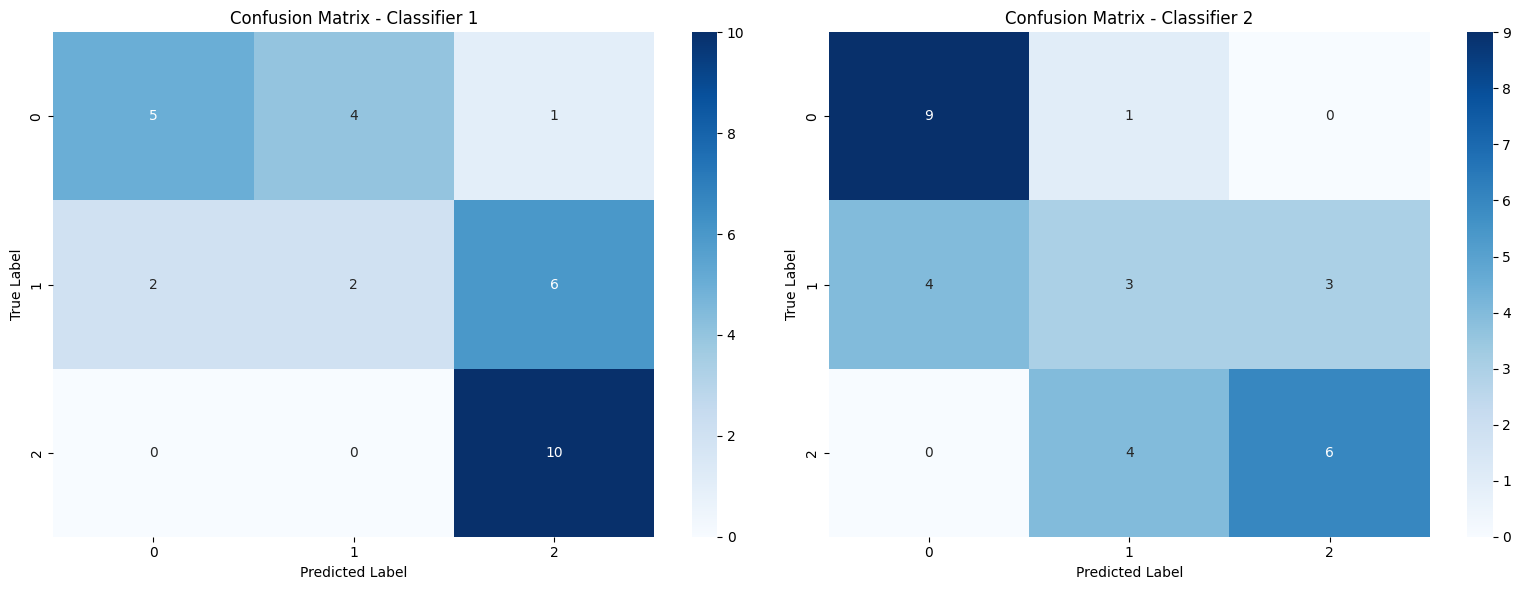

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrices first
cm1 = confusion_matrix(y_true, y_pred_clf1)
cm2 = confusion_matrix(y_true, y_pred_clf2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix for Classifier 1
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Classifier 1')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix for Classifier 2
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Classifier 2')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()